In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy as sp
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, roc_curve
from datetime import timedelta

from sklearn.calibration import calibration_curve
import shap

from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score, accuracy_score, precision_recall_curve
import optuna

# Suprimindo logs excessivos do Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuração de Estilo
plt.style.use('dark_background')
shap.initjs()

# Configuração visual de alto padrão
plt.style.use('dark_background')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

In [47]:
config = {
    "data":['../src/ifrs9_framework/data/raw/synthetic_credit_data.parquet'],
    "num_columns": ['idade', 'renda', 'bureau_score', 'prazo_meses', 'limite_credito', 'valor_financiado', 'selic_contratacao'],
    "cat_columns": ['uf', 'tipo_produto'],
    "target": ['default_flag'],
    "features_radar": ['idade', 'bureau_score', 'renda_yj', 'limite_credito_yj', 'valor_financiado_yj'],
    "features_model": [
        'idade', 'bureau_score', 'selic_contratacao', 'prazo_meses',
        'renda_yj', 'limite_credito_yj', 'valor_financiado_yj', # Variáveis Curadas
        'tipo_produto', 'zona_risco_flag', 'anomalia_multivariada' # Categóricas e Radar
    ]
}

In [50]:
def read_parquet(config):
    df = pd.read_parquet(config['data'][0])
    print(f"Total de Contratos Analisados: \n{len(df)}")
    print(f"========================================================")
    # print(f"info dataframe: \n{df.info()}")
    display(df.info())
    print(f"========================================================")
    # print(f"\n{df.describe().round(2)}")
    display(df.describe().round(2))
    print(f"========================================================")
    return df


def calcular_coeficiente(df, list_columns):
    print("--- DIAGNÓSTICO DE VOLATILIDADE (COEFICIENTE DE VARIAÇÃO) ---\n")
    for col in list_columns:
        # Usamos 'col' para acessar especificamente a coluna da iteração atual
        cv = df[col].std() / df[col].mean()
        
        # Adicionando uma lógica de semáforo visual para facilitar a leitura
        alerta = "🔴 ALTO" if cv > 1.0 else "🟡 MÉDIO" if cv > 0.3 else "🟢 BAIXO"
        display(f"{col.ljust(20)} | CV: {cv:.4f} ({cv * 100:>6.2f}%) | Risco de Outliers: {alerta}")
    return alerta, cv

def plot_space_vectors(df, config):
    # features select
    num_features = config['num_columns']
    cat_features = config['cat_columns'][1]

    print(f"features numericas carregadas: \n{num_features}")
    print(f"features categoricas carregadas: \n{cat_features}")
    # build df features
    df_features = pd.get_dummies(df[num_features + [cat_features]], columns=[cat_features])
    
    # Padronização (Crucial para o PCA: média 0, variância 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features)
    
    # Reduzindo dezenas de colunas para apenas 2 eixos principais (X e Y vetoriais)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    df['pca_1'] = X_pca[:, 0]
    df['pca_2'] = X_pca[:, 1]
    print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")

    print("\n4. Aplicando K-Means (Buscando 4 nichos de comportamento)...")
    kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
    df['cluster_id'] = kmeans.fit_predict(X_scaled)

    # ================= VIZUALIZAÇÃO =================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Gráfico 1: A separação matemática dos clusters
    sns.scatterplot(
        data=df.sample(20000), # Amostra para não travar a renderização gráfica
        x='pca_1', y='pca_2', 
        hue='cluster_id', 
        palette='viridis', 
        alpha=0.6, 
        ax=ax1
    )
    ax1.set_title("Espaço Vetorial (PCA) - Separação de Clusters")
    ax1.set_xlabel("Componente Principal 1 (Risco Estrutural)")
    ax1.set_ylabel("Componente Principal 2 (Comportamento de Crédito)")
    
    # Gráfico 2: Prova de Fogo (Inadimplência por Cluster)
    taxa_default_cluster = df.groupby('cluster_id')['default_flag'].mean() * 100
    sns.barplot(x=taxa_default_cluster.index, y=taxa_default_cluster.values, palette='viridis', ax=ax2)
    ax2.set_title("Taxa Real de Inadimplência (Default) por Cluster")
    ax2.set_ylabel("Inadimplência (%)")
    ax2.set_xlabel("ID do Cluster")
    
    # Adicionando o rótulo de dados no gráfico de barras
    for i, v in enumerate(taxa_default_cluster.values):
        ax2.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n5. Perfil de Risco (A Resposta do Estudo):")
    # Descobrindo o que cada cluster representa no mundo real
    perfil = df.groupby('cluster_id').agg({
        'tipo_produto': lambda x: x.value_counts().index[0], # Produto dominante no cluster
        'bureau_score': 'mean',
        'renda': 'mean',
        'default_flag': 'mean'
    }).rename(columns={'default_flag': 'taxa_default'})
    perfil['taxa_default'] = (perfil['taxa_default'] * 100).round(1).astype(str) + '%'
    
    display(perfil)

    print("--- INICIANDO ENGENHARIA DE FEATURES (YEO-JOHNSON) ---")

    # Vamos focar nas colunas que gritaram ALTO risco no seu diagnóstico
    colunas_criticas = ['renda', 'limite_credito', 'valor_financiado']
    
    # Inicializamos o transformador de potência (Yeo-Johnson é o padrão)
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    
    # Criamos cópias para não destruir os dados originais no dataframe
    for col in colunas_criticas:
        nome_nova_col = f"{col}_yj"
        # O fit_transform exige um formato 2D, por isso os dois colchetes
        df[nome_nova_col] = pt.fit_transform(df[[col]])
        print(f"Transformação concluída para: {col} -> {nome_nova_col}")
    
    print("\n--- NOVO DIAGNÓSTICO DE VOLATILIDADE (PÓS-CURA) ---")
    
    colunas_curadas = [f"{c}_yj" for c in colunas_criticas]
    
    fig, axes = plt.subplots(1, len(colunas_criticas), figsize=(18, 5))
    
    for i, col in enumerate(colunas_curadas):
        # Calculando o novo CV (Nota: como standardizamos, a média é ~0, então olhamos a distribuição visual)
        # Plotando o antes e o depois
        
        sns.kdeplot(df[col], ax=axes[i], fill=True, color='cyan')
        axes[i].set_title(f"Distribuição Pós Yeo-Johnson\n{col}")
        axes[i].set_xlabel("Valor Transformado (Z-score)")
        axes[i].set_ylabel("Densidade")
    
    plt.tight_layout()
    plt.show()
    
    print("Verifique os gráficos: A assimetria severa desapareceu. Onde havia caudas longas, agora temos sinos estabilizados.")
    return df

def analise_anomalias(df, config):

    print("--- INICIANDO RADAR DE ANOMALIAS (MAHALANOBIS OTIMIZADO) ---")
    
    features_radar = config['features_radar']
    df_radar = df[features_radar].copy()
    
    # OTIMIZAÇÃO DE MEMÓRIA (Evitando a explosão da matriz N x N)
    def calculate_mahalanobis_optimized(y=None, data=None, cov=None):
        y_mu = y - np.mean(data, axis=0)
        if not cov:
            cov = np.cov(data.values.T)
        inv_covmat = sp.linalg.inv(cov)
        left_term = np.dot(y_mu, inv_covmat)
        
        # A correção mágica: multiplicação element-wise e soma pelo eixo 1.
        # Extrai diretamente a diagonal da matriz teórica, gastando zero RAM extra.
        mahal = np.sum(left_term * y_mu, axis=1)
        return mahal
    
    # Calculando a distância instantaneamente
    df['distancia_mahalanobis'] = calculate_mahalanobis_optimized(y=df_radar, data=df_radar)
    
    graus_liberdade = len(features_radar)
    limiar_anomalia = chi2.ppf((1 - 0.005), graus_liberdade)
    df['anomalia_multivariada'] = (df['distancia_mahalanobis'] > limiar_anomalia).astype(int)
    
    anomalias_encontradas = df['anomalia_multivariada'].sum()
    print(f"\nLimiar Matemático (Chi-Square): {limiar_anomalia:.2f}")
    print(f"Total de Anomalias Detectadas: {anomalias_encontradas} ({anomalias_encontradas/len(df)*100:.2f}%)")
    
    # ================= VIZUALIZAÇÃO INTELIGENTE =================
    fig, ax = plt.subplots(figsize=(12, 6))
    
    normais = df[df['anomalia_multivariada'] == 0]
    anomalias = df[df['anomalia_multivariada'] == 1]
    
    # Amostragem assimétrica: Plotamos só 30k normais, mas 100% das fraudes.
    amostra_normais = normais.sample(n=min(30000, len(normais)), random_state=42)
    
    ax.scatter(amostra_normais['idade'], amostra_normais['renda_yj'], color='cyan', alpha=0.1, label='Base Saudável (Amostra)', s=5)
    ax.scatter(anomalias['idade'], anomalias['renda_yj'], color='#ff3333', edgecolors='white', label='Anomalias (100%)', s=25)
    
    ax.set_title("Detecção de Fraude/Outliers no Espaço Multidimensional\n(Idade vs Renda Normalizada)")
    ax.set_xlabel("Idade do Cliente")
    ax.set_ylabel("Renda (Transformada Yeo-Johnson)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print("\nTaxa de Default - Base Saudável vs Anomalias:")
    display(df.groupby('anomalia_multivariada')[['default_flag', 'churn_flag', 'valor_financiado']].mean())
    return df

def model_training(df, config):

    print("--- 1. PREPARAÇÃO DA MÁQUINA DO TEMPO (OUT-OF-TIME) ---")
    
    # Ordenamos a base estritamente pela data de contratação
    df = df.sort_values('data_contratacao').reset_index(drop=True)
    
    # O ponto de corte será os 80% mais antigos para treino, e os 20% mais recentes para teste
    corte_idx = int(len(df) * 0.8)
    train_df = df.iloc[:corte_idx]
    test_df = df.iloc[corte_idx:]
    
    data_corte = train_df['data_contratacao'].max().strftime('%Y-%m-%d')
    print(f"Data de Corte OOT: {data_corte}")
    print(f"Treino (Passado): {len(train_df)} contratos | Teste (Futuro): {len(test_df)} contratos")
    
    # Definindo quem é variável explicativa (X) e quem é o alvo (y)
    features = [
        'idade', 'bureau_score', 'selic_contratacao', 'prazo_meses',
        'renda_yj', 'limite_credito_yj', 'valor_financiado_yj', # Variáveis Curadas
        'tipo_produto', 'zona_risco_flag', 'anomalia_multivariada' # Categóricas e Radar
    ]
    cat_features = ['tipo_produto'] # O CatBoost engole texto puro sem precisar de One-Hot Encoding!
    
    X_train, y_train = train_df[features], train_df['default_flag']
    X_test, y_test = test_df[features], test_df['default_flag']

    print("\n--- 2. INICIANDO TREINAMENTO: CATBOOST CLASSIFIER ---")
    peso_calibrado = 10 
    
    model_cirurgico = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=peso_calibrado, # Substitui o 'auto_class_weights'
        cat_features=['tipo_produto'],
        eval_metric='AUC',
        random_seed=42,
        verbose=0 # Silenciando o log para ir direto ao resultado
    )
    
    print(f"Treinando modelo com scale_pos_weight = {peso_calibrado}...")
    model_cirurgico.fit(X_train, y_train)
    
    print("\n--- 2. CALIBRAÇÃO ISOTÔNICA E MESA DE CRÉDITO ---")
    
    # Previsão e Calibração
    y_train_proba = model_cirurgico.predict_proba(X_train)[:, 1]
    iso_reg = IsotonicRegression(out_of_bounds='clip')
    iso_reg.fit(y_train_proba, y_train)
    
    y_test_proba = model_cirurgico.predict_proba(X_test)[:, 1]
    pd_calibrada_cirurgica = iso_reg.transform(y_test_proba)
    
    # Usando o mesmo Cut-off anterior para termos comparação justa (4%)
    nota_de_corte = 0.04
    previsoes_cirurgicas = (pd_calibrada_cirurgica > nota_de_corte).astype(int)
    
    cm_nova = confusion_matrix(y_test, previsoes_cirurgicas)

    # ================= VIZUALIZAÇÃO =================
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(cm_nova, annot=True, fmt='d', cmap='Greens', ax=ax, 
                xticklabels=['Aprovado (0)', 'Negado (1)'], 
                yticklabels=['Bom Pagador (0)', 'Inadimplente (1)'])
    ax.set_title(f"Nova Matriz de Confusão - Modelo Cirúrgico (Cut-off: {nota_de_corte*100}%)")
    ax.set_ylabel("Mundo Real")
    ax.set_xlabel("Decisão do Modelo")
    plt.tight_layout()
    plt.show()
    
    print("\n--- 3. RESULTADO DA AUDITORIA COMERCIAL ---")
    # Falso Positivo: Linha 0 (Bons), Coluna 1 (Negados)
    falsos_positivos_novos = cm_nova[0, 1]
    # Antigo número da sua imagem era 13.151
    falsos_positivos_antigos = 13151 
    
    clientes_salvos = falsos_positivos_antigos - falsos_positivos_novos
    
    print(classification_report(y_test, previsoes_cirurgicas, target_names=['Bons Pagadores', 'Inadimplentes']))
    print(f"==================================================")
    print(f"Bons Pagadores Negados Injustamente (Antes): {falsos_positivos_antigos}")
    print(f"Bons Pagadores Negados Injustamente (Agora): {falsos_positivos_novos}")
    print(f"RECEITA SALVA (Contratos Aprovados Corretamente): {clientes_salvos} clientes!")
    print(f"==================================================")

    return model_cirurgico, X_train, y_train, X_test, y_test

In [41]:
df = read_parquet(config)

Total de Contratos Analisados: 
374486
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374486 entries, 0 to 374485
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   cliente_id         374486 non-null  int64         
 1   idade              374486 non-null  float64       
 2   renda              374486 non-null  float64       
 3   uf                 374486 non-null  object        
 4   zona_risco_flag    374486 non-null  int64         
 5   bureau_score       374486 non-null  float64       
 6   obito_flag         374486 non-null  int64         
 7   codigo_contrato    374486 non-null  object        
 8   tipo_produto       374486 non-null  object        
 9   data_contratacao   374486 non-null  datetime64[ns]
 10  prazo_meses        374486 non-null  int64         
 11  data_vencimento    374486 non-null  datetime64[ns]
 12  limite_credito     374486 non-null  float64       
 13  valor

None

,cliente_id,idade,renda,zona_risco_flag,bureau_score,obito_flag,data_contratacao,prazo_meses,data_vencimento,limite_credito,valor_financiado,selic_contratacao,default_flag,churn_flag,data_evento
count,374486.00,374486.00,374486.00,374486.0,374486.00,374486.00,374486,374486.00,374486,374486.00,374486.00,374486.00,374486.00,374486.00,374486
mean,75040.21,52.06,5741.52,0.1,649.75,0.01,2023-12-24 00:14:37.413841920,64.58,2029-04-13 06:36:22.460225024,948.00,18559.94,7.87,0.02,0.12,2028-09-04 15:16:35.136800
min,1.00,18.00,1320.00,0.0,80.38,0.00,2021-07-09 00:00:00,12.00,2022-07-05 00:00:00,0.00,0.00,2.00,0.00,0.00,2021-08-08 00:00:00
25%,37542.00,42.58,1689.46,0.0,562.34,0.00,2022-10-01 00:00:00,37.00,2027-08-03 00:00:00,0.00,3211.66,4.93,0.00,0.00,2026-04-24 00:00:00
50%,74973.00,52.03,2398.80,0.0,649.61,0.00,2023-12-24 00:00:00,73.00,2029-06-16 00:00:00,0.00,7174.74,7.87,0.00,0.00,2028-10-28 00:00:00
75%,112533.00,61.48,4372.01,0.0,737.93,0.00,2025-03-17 00:00:00,84.00,2031-03-26 00:00:00,0.00,14633.03,10.81,0.00,0.00,2030-11-25 00:00:00
max,150000.00,95.00,150000.00,1.0,1000.00,1.00,2026-06-11 00:00:00,120.00,2036-04-04 00:00:00,50000.00,2258523.87,13.75,1.00,1.00,2036-04-04 00:00:00
std,43316.78,13.90,13709.69,0.3,129.75,0.08,NaN,25.34,NaN,4309.27,58423.78,3.39,0.13,0.32,NaN


In [42]:
alerta, cv = calcular_coeficiente(df, config["num_columns"])

--- DIAGNÓSTICO DE VOLATILIDADE (COEFICIENTE DE VARIAÇÃO) ---



'idade                | CV: 0.2670 ( 26.70%) | Risco de Outliers: 🟢 BAIXO'

'renda                | CV: 2.3878 (238.78%) | Risco de Outliers: 🔴 ALTO'

'bureau_score         | CV: 0.1997 ( 19.97%) | Risco de Outliers: 🟢 BAIXO'

'prazo_meses          | CV: 0.3925 ( 39.25%) | Risco de Outliers: 🟡 MÉDIO'

'limite_credito       | CV: 4.5456 (454.56%) | Risco de Outliers: 🔴 ALTO'

'valor_financiado     | CV: 3.1478 (314.78%) | Risco de Outliers: 🔴 ALTO'

'selic_contratacao    | CV: 0.4309 ( 43.09%) | Risco de Outliers: 🟡 MÉDIO'

features numericas carregadas: 
['idade', 'renda', 'bureau_score', 'prazo_meses', 'limite_credito', 'valor_financiado', 'selic_contratacao']
features categoricas carregadas: 
tipo_produto
Variância explicada pelos 2 componentes: 38.75%

4. Aplicando K-Means (Buscando 4 nichos de comportamento)...


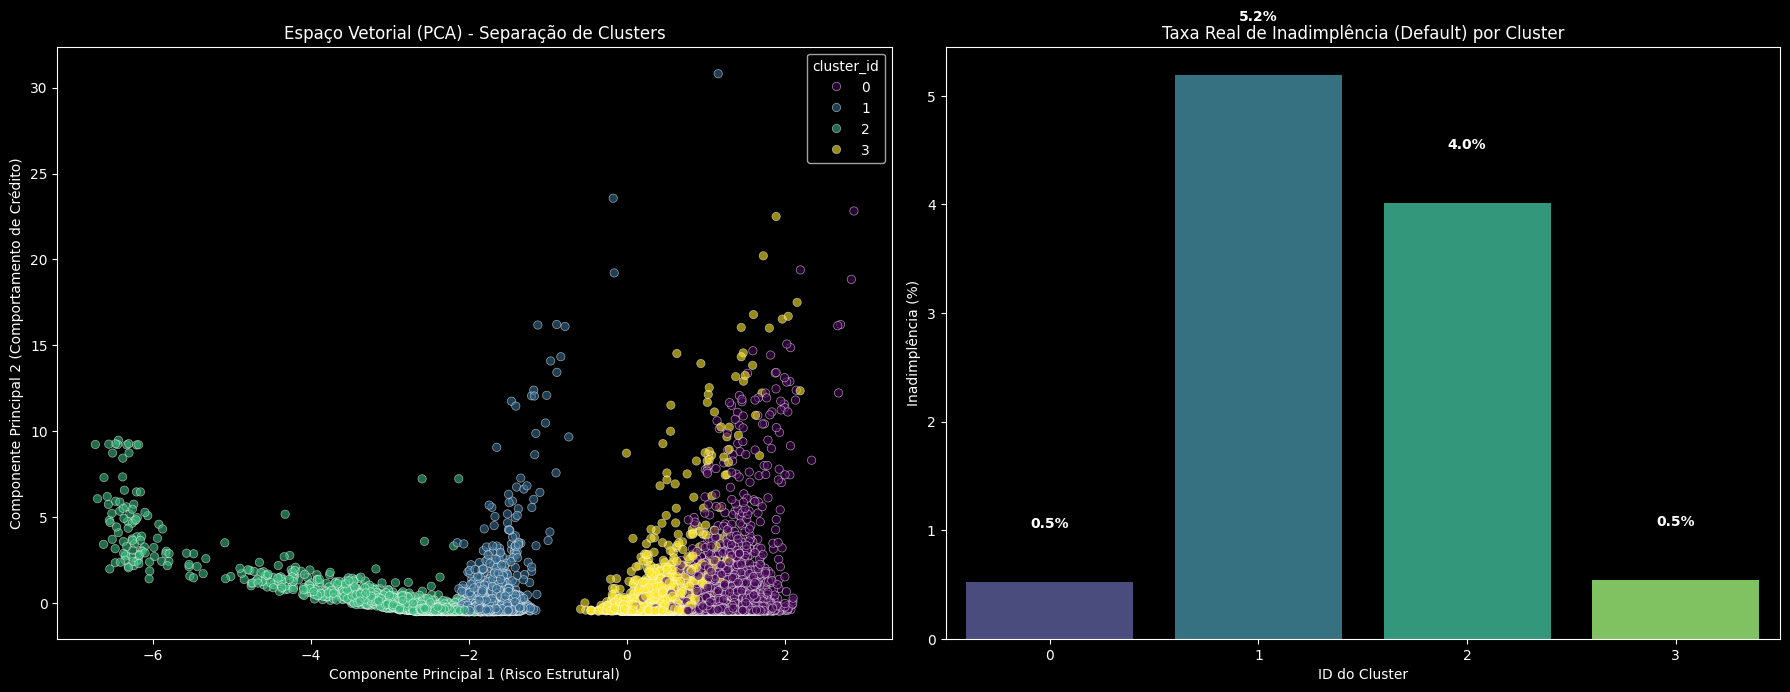


5. Perfil de Risco (A Resposta do Estudo):


,tipo_produto,bureau_score,renda,taxa_default
cluster_id,,,,
0,Consignado INSS,649.221575,5738.959397,0.5%
1,Crédito Pessoal,650.684661,5758.419440,5.2%
2,Cartão de Crédito,650.402747,5747.364353,4.0%
3,Consignado SIAPE,649.902306,5730.931085,0.5%


--- INICIANDO ENGENHARIA DE FEATURES (YEO-JOHNSON) ---
Transformação concluída para: renda -> renda_yj
Transformação concluída para: limite_credito -> limite_credito_yj
Transformação concluída para: valor_financiado -> valor_financiado_yj

--- NOVO DIAGNÓSTICO DE VOLATILIDADE (PÓS-CURA) ---


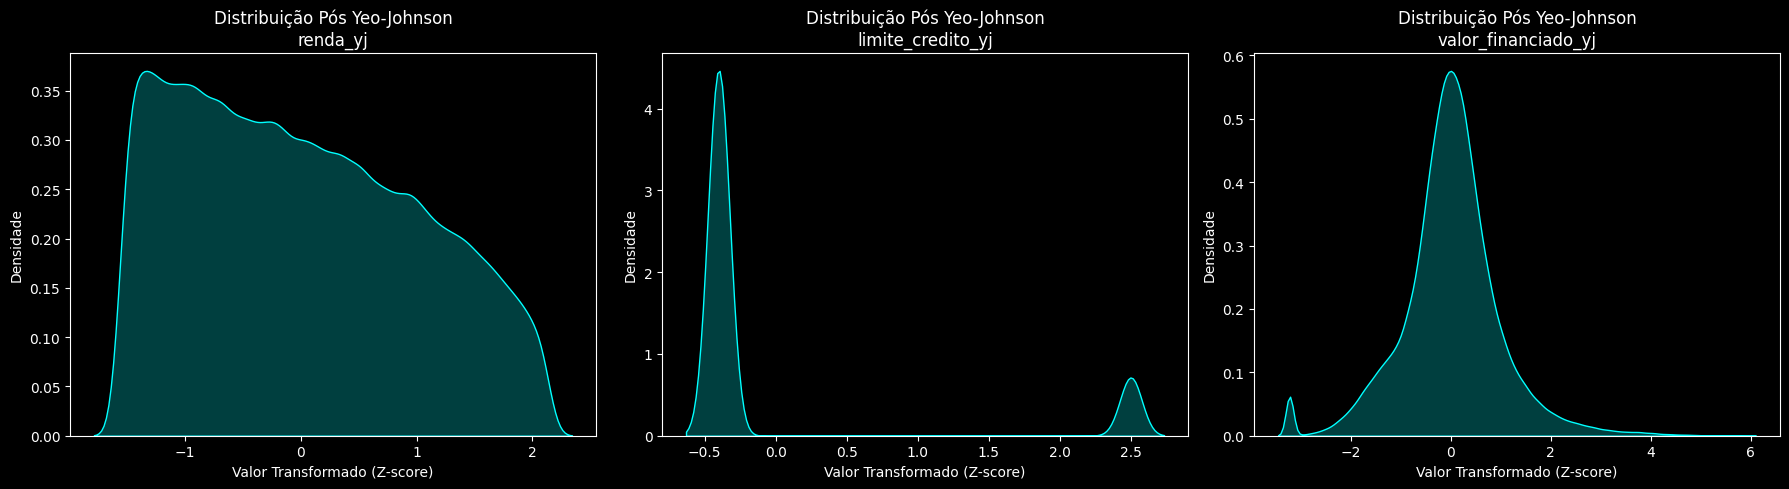

Verifique os gráficos: A assimetria severa desapareceu. Onde havia caudas longas, agora temos sinos estabilizados.


In [43]:
df = plot_space_vectors(df, config)

--- INICIANDO RADAR DE ANOMALIAS (MAHALANOBIS OTIMIZADO) ---

Limiar Matemático (Chi-Square): 16.75
Total de Anomalias Detectadas: 7474 (2.00%)


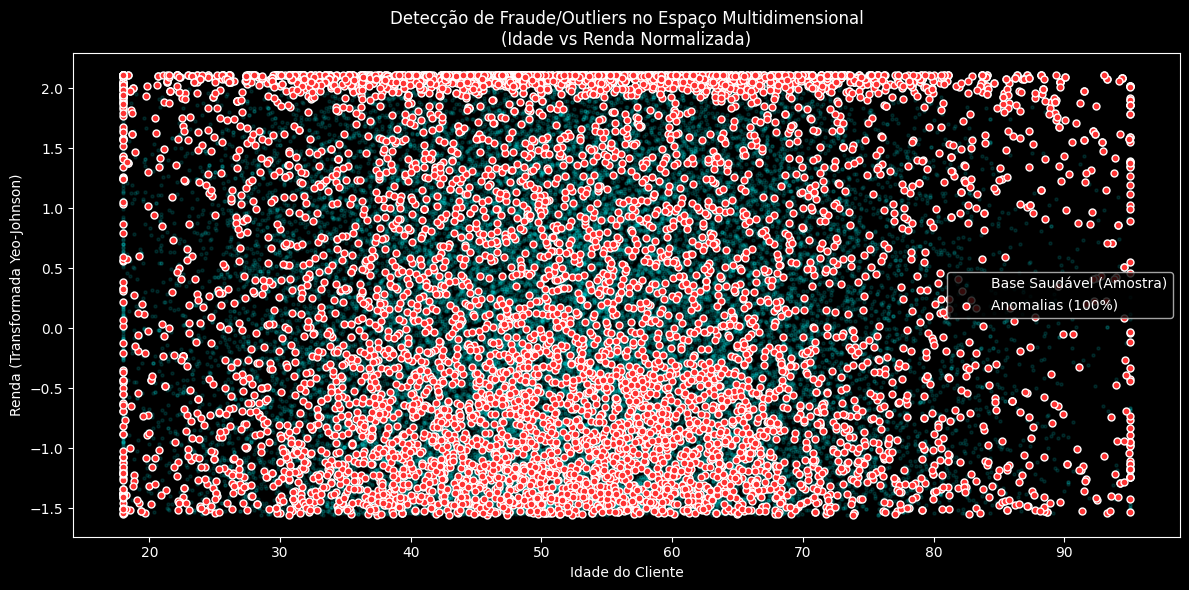


Taxa de Default - Base Saudável vs Anomalias:


,default_flag,churn_flag,valor_financiado
anomalia_multivariada,,,
0,0.017196,0.119754,15397.907230
1,0.029971,0.076398,173831.944604


In [45]:
df = analise_anomalias(df, config)

In [46]:
df.head()

,cliente_id,idade,renda,uf,zona_risco_flag,bureau_score,obito_flag,codigo_contrato,tipo_produto,data_contratacao,...,churn_flag,data_evento,pca_1,pca_2,cluster_id,renda_yj,limite_credito_yj,valor_financiado_yj,distancia_mahalanobis,anomalia_multivariada
0,1,58.953998,2302.091770,MA,1,458.690273,0,4f2c04d0,Consignado SIAPE,2021-11-06,...,0,2028-05-03,0.428751,-0.311339,3,-0.179816,-0.400021,0.270036,2.667597,0
1,1,58.953998,2302.091770,MA,1,458.690273,0,de9929d6,Consignado SIAPE,2022-06-12,...,0,2030-01-31,0.747913,-0.338490,3,-0.179816,-0.400021,0.014531,2.625964,0
2,1,58.953998,2302.091770,MA,1,458.690273,0,ca147a05,Consignado INSS,2023-01-17,...,1,2024-09-08,1.392667,-0.354609,0,-0.179816,-0.400021,-0.182161,2.793439,0
3,2,50.064300,5547.355046,RJ,0,588.041646,0,f833304b,Consignado INSS,2023-01-26,...,0,2030-11-15,1.502266,-0.156815,0,1.039740,-0.400021,0.123300,2.458312,0
4,3,61.067640,3537.639538,MA,0,671.794326,0,5262dd9b,Consignado INSS,2022-06-09,...,1,2022-10-07,1.284569,0.003545,0,0.525440,-0.400021,1.050940,1.588614,0


--- 1. PREPARAÇÃO DA MÁQUINA DO TEMPO (OUT-OF-TIME) ---
Data de Corte OOT: 2025-06-15
Treino (Passado): 299588 contratos | Teste (Futuro): 74898 contratos

--- 2. INICIANDO TREINAMENTO: CATBOOST CLASSIFIER ---
Treinando modelo com scale_pos_weight = 10...

--- 2. CALIBRAÇÃO ISOTÔNICA E MESA DE CRÉDITO ---


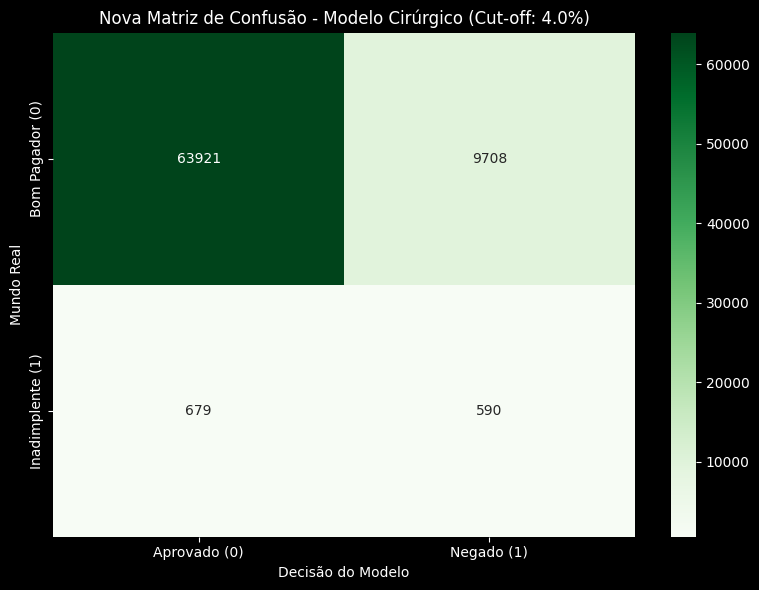


--- 3. RESULTADO DA AUDITORIA COMERCIAL ---
                precision    recall  f1-score   support

Bons Pagadores       0.99      0.87      0.92     73629
 Inadimplentes       0.06      0.46      0.10      1269

      accuracy                           0.86     74898
     macro avg       0.52      0.67      0.51     74898
  weighted avg       0.97      0.86      0.91     74898

Bons Pagadores Negados Injustamente (Antes): 13151
Bons Pagadores Negados Injustamente (Agora): 9708
RECEITA SALVA (Contratos Aprovados Corretamente): 3443 clientes!


In [51]:
model, X_train, y_train, X_test, y_test = model_training(df, config)